# LSM Option Pricing Engine - Quick Start Demo
This notebook demonstrates how to price an American Put option using the `lsm-option-pricing` library.

In [21]:
# Install the package (Required for Google Colab compatibility)
# !pip install lsm-option-pricing --quiet

Alternatively, to run locally, run the following:

In [22]:
import sys
import os
sys.path.append(os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from LSM.stochastic_processes import GeometricBrownianMotion
from LSM.payoffs import VanillaPayoff
from LSM.regression_bases import LaguerrePolynomials
from LSM.algorithms import LeastSquaresMonteCarlo

print("Libraries imported successfully!")

Libraries imported successfully!


### Setup for 1D

In [24]:
# 1. Setup Market Parameters and Features
gbm = GeometricBrownianMotion(S0=36.0, r=0.06, q=0.0, sigma=0.2)
put_payoff = VanillaPayoff(strike=40.0, option_type="put")
laguerre_basis = LaguerrePolynomials(degree=3)

# 2. Initialize the Engine
lsm_engine = LeastSquaresMonteCarlo(
    process=gbm,
    payoff_function=put_payoff,
    basis_function=laguerre_basis
)

# 3. Price the American Put Option
price, std = lsm_engine.pricer(T=1.0, n_steps=50, n_paths=10000, rng=np.random.default_rng(42))

print(f"American Put Price Estimate: {price:.4f}")
print(f"Standard Error: ±{std:.4f}")

American Put Price Estimate: 4.4916
Standard Error: ±0.0299


### Sanity Check: American Call vs. European Call
It is a known mathematical property that an American Call option on a non-dividend paying stock ($q=0$) should not be exercised early, making its price equivalent to a standard European Call option. Let's verify our engine against the analytical Black-Scholes-Merton (BSM) formula.

In [25]:
from scipy import stats

def bsm_european_call(S0, K, T, r, q, sigma):
    d1 = (np.log(S0/K) + (r - q + 0.5*(sigma**2))*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return np.exp(-q*T) * S0 * stats.norm.cdf(d1) - np.exp(-r*T) * K * stats.norm.cdf(d2)

# Parameters
S0, K, T, r, q, sigma = 36.0, 40.0, 1.0, 0.06, 0.0, 0.2

# 1. Analytical BSM Price
bsm_call_price = bsm_european_call(S0, K, T, r, q, sigma)

# 2. LSM Engine Price
gbm_call = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
call_payoff = VanillaPayoff(strike=K, option_type="call")
lsm_engine_call = LeastSquaresMonteCarlo(process=gbm_call, payoff_function=call_payoff, basis_function=laguerre_basis)

lsm_call_price, lsm_call_std = lsm_engine_call.pricer(T=T, n_steps=50, n_paths=10000, rng=np.random.default_rng(42))

print(f"BSM Analytical European Call: {bsm_call_price:.4f}")
print(f"LSM Engine American Call:     {lsm_call_price:.4f} ± {lsm_call_std:.4f}")
print(f"Absolute Error:               {abs(bsm_call_price - lsm_call_price):.4f}")

BSM Analytical European Call: 2.1737
LSM Engine American Call:     2.1472 ± 0.0388
Absolute Error:               0.0265


### Visualization: Error Convergence

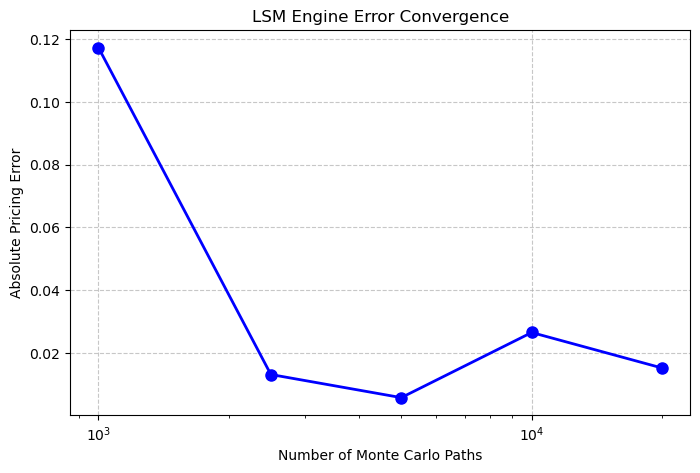

In [26]:
# Demonstrating how the LSM price converges to the theoretical true price as paths increase.
paths_to_test = [1000, 2500, 5000, 10000, 20000]
errors = []

for n in paths_to_test:
    price, _ = lsm_engine_call.pricer(T=1.0, n_steps=50, n_paths=n, rng=np.random.default_rng(42))
    errors.append(abs(price - bsm_call_price))

plt.figure(figsize=(8, 5))
plt.plot(paths_to_test, errors, 'bo-', linewidth=2, markersize=8)
plt.title('LSM Engine Error Convergence')
plt.xlabel('Number of Monte Carlo Paths')
plt.ylabel('Absolute Pricing Error')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Advanced Payoff Structures

While the engine easily handles vanilla 1D options, its true power lies in pricing complex, path-dependent, and high-dimensional derivatives. Below we demonstrate pricing a **5-Asset American Max Call** and a **Commodity Swing Option**.

### High-Dimensional Pricing: 5-Asset American Max Call
Standard finite difference methods suffer from the "curse of dimensionality" when pricing basket options. The LSM engine handles this seamlessly using Cholesky decomposition for correlated asset paths.

Here, we simulate 5 identical assets with a constant cross-correlation of 0.3. The payoff is based on the maximum asset price in the basket at the time of exercise.

In [27]:
from LSM.payoffs import AmericanMaxCall

# 1. Setup 5-Asset Parameters
n_assets = 5
S0 = np.array([36.0] * n_assets)
q = np.array([0.0] * n_assets)
sigma = np.array([0.2] * n_assets)
r = 0.06

# Create a constant correlation matrix (0.3 cross-correlation)
corr_matrix = np.full((n_assets, n_assets), 0.3)
np.fill_diagonal(corr_matrix, 1.0)

# 2. Initialize Multi-Asset Process and Payoff
gbm_multi = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma, correlation_matrix=corr_matrix)
max_call_payoff = AmericanMaxCall(strike=40.0) 
basis = LaguerrePolynomials(degree=3)

# 3. Price the Max Call
lsm_multi = LeastSquaresMonteCarlo(
    process=gbm_multi, 
    payoff_function=max_call_payoff, 
    basis_function=basis
)

max_call_price, max_call_std = lsm_multi.pricer(
    T=1.0, 
    n_steps=50, 
    n_paths=20000, 
    rng=np.random.default_rng(42)
)

print(f"5-Asset Max Call Price: {max_call_price:.4f} ± {max_call_std:.4f}")

5-Asset Max Call Price: 5.5602 ± 0.0320


### Path-Dependent Pricing: Commodity Swing Options
Swing options are common in energy markets (gas and electricity), giving the holder flexibility in the timing and volume of energy delivery. 

Unlike a standard American option which is exercised once, a swing option can be exercised multiple times up to a maximum global constraint. The engine handles this by adding a second dimension to the state space: the number of remaining exercise rights.

In [28]:
from LSM.payoffs import SwingSpread
from LSM.regression_bases import PowerPolynomials

# 1. Setup Base Process for the Underlying Commodity
# (Assuming a single underlying energy price for simplicity)
gbm_commodity = GeometricBrownianMotion(S0=36.0, r=0.06, q=0.0, sigma=0.4)

# 2. Initialize Swing Features
total_rights = 5

# SwingSpread only takes option_type
swing_payoff = SwingSpread(option_type="call")
basis = PowerPolynomials(degree=3)

# 3. Price the Swing Option
lsm_swing = LeastSquaresMonteCarlo(
    process=gbm_commodity, 
    payoff_function=swing_payoff, 
    basis_function=basis
)

# swing_pricer requires an array of contract prices (strikes) for each time step
n_steps = 50
contract_prices_array = np.full(n_steps + 1, 40.0) 


# Call swing_pricer and pass the specific swing parameters
swing_price, swing_std = lsm_swing.swing_pricer(
    T=1.0, # Total time to maturity (in years)
    n_steps=n_steps, # Number of discrete time steps
    n_paths=10000, # Number of Monte Carlo paths to simulate
    rng=np.random.default_rng(42), # Random seed for reproducible results
    contract_prices=contract_prices_array, # Fixed strike/forward curve at each step
    DCQ=1.0, # Daily Contract Quantity (max volume per exercise)
    Ed=total_rights, # Total number of exercise rights available
    ToP_rights=0 # Minimum required exercises (Take-or-Pay threshold)
)

print(f"Commodity Swing Option Price (Rights={total_rights}): {swing_price:.4f} ± {swing_std:.4f}")

Commodity Swing Option Price (Rights=5): 23.7622 ± 0.3991


### FX / Quanto Option Pricing Demo

This section demonstrates fixed-FX quanto pricing. The stock process uses the quanto drift adjustment, and the payoff is converted using a fixed FX rate.

In [29]:
from LSM.payoffs import QuantoPut
from LSM.stochastic_processes import QuantoGBM

fixed_quanto_process = QuantoGBM(
    S0=100,
    r_dom=0.05,
    r_for=0.02,
    q=0.0,
    sigma_s=0.20,
    sigma_fx=0.10,
    rho_sfx=0.30,
)

fixed_quanto_payoff = QuantoPut(strike=100, fx_fix=1.20)

fixed_quanto_engine = LeastSquaresMonteCarlo(
    process=fixed_quanto_process,
    payoff_function=fixed_quanto_payoff,
    basis_function=LaguerrePolynomials(degree=3),
)

fixed_quanto_price, fixed_quanto_stderr = fixed_quanto_engine.pricer(
    T=1.0,
    n_steps=20,
    n_paths=10000,
    rng=np.random.default_rng(42),
    use_antithetic=True,
)

print(f"Fixed-rate quanto put price: {fixed_quanto_price:.4f}")
print(f"Standard error: {fixed_quanto_stderr:.4f}")

Fixed-rate quanto put price: 8.6468
Standard error: 0.1020


In [30]:
from LSM.payoffs import QuantoRateFeatures
from LSM.stochastic_processes import QuantoStochasticRatesProcess

# State columns are [stock price, domestic short rate, foreign short rate].
stoch_quanto_process = QuantoStochasticRatesProcess(
    S0=100,
    rd0=0.05,
    rf0=0.02,
    q=0.0,
    sigma_s=0.20,
    sigma_fx=0.10,
    rho_sfx=0.30,
    a_d=1.0,
    b_d=0.05,
    sigma_d=0.01,
    a_f=1.0,
    b_f=0.02,
    sigma_f=0.01,
)

stoch_quanto_payoff = QuantoPut(strike=100, fx_fix=1.20, column=0)

stoch_quanto_engine = LeastSquaresMonteCarlo(
    process=stoch_quanto_process,
    payoff_function=stoch_quanto_payoff,
    basis_function=LaguerrePolynomials(degree=3),
)

stoch_quanto_price, stoch_quanto_stderr = stoch_quanto_engine.pricer(
    T=1.0,
    n_steps=20,
    n_paths=10000,
    rng=np.random.default_rng(43),
    use_antithetic=True,
    create_features=QuantoRateFeatures(strike=100),
)

print(f"Stochastic-rate quanto put price: {stoch_quanto_price:.4f}")
print(f"Standard error: {stoch_quanto_stderr:.4f}")

Stochastic-rate quanto put price: 8.5426
Standard error: 0.0997
